# Explainability — SHAP
**TFG: Evaluación del riesgo de ciberseguridad en PYMES basada en modelos de Machine Learning explicables**

This notebook applies SHAP (SHapley Additive exPlanations) to interpret the Random Forest model trained in `02_modelo.ipynb`.

Sections:
1. Load model and test data
2. Compute SHAP values
3. Global explainability — feature importance
4. Global explainability — feature impact direction
5. Local explainability — individual CVE analysis
6. Key findings for the thesis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

plt.rcParams['figure.dpi'] = 120

MODEL_PATH  = '../models/random_forest.pkl'
X_TEST_PATH = '../data/processed/X_test.csv'
Y_TEST_PATH = '../data/processed/y_test.csv'

## 1. Load Model and Test Data

In [6]:
rf      = joblib.load(MODEL_PATH)
X_test  = pd.read_csv(X_TEST_PATH)
y_test  = pd.read_csv(Y_TEST_PATH).squeeze()

print(f'Model loaded:    Random Forest ({rf.n_estimators} trees)')
print(f'Test samples:    {len(X_test):,}')
print(f'Features:        {len(X_test.columns)}')
print(f'Positive class:  {y_test.sum():,}  ({y_test.mean()*100:.2f}%)')

Model loaded:    Random Forest (200 trees)
Test samples:    54,500
Features:        24
Positive class:  274  (0.50%)


## 2. Compute SHAP Values

SHAP TreeExplainer is used because it is optimised for tree-based models and runs significantly faster than the model-agnostic explainer.

A sample of 2,000 records is used for visualisation to keep computation time reasonable while maintaining statistical representativeness.

In [7]:
# Use a representative sample for SHAP computation
SAMPLE_SIZE = 2000
X_sample = X_test.sample(n=SAMPLE_SIZE, random_state=42)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# shap_values is a list of two arrays: [class_0, class_1]
# We use class_1 (exploited) for all analysis
if isinstance(shap_values, list):
    shap_exploited = shap_values[1]
else:
    shap_exploited = shap_values[:, :, 1]

print(f'SHAP values computed for {SAMPLE_SIZE} samples')
print(f'SHAP array shape: {shap_exploited.shape}')

SHAP values computed for 2000 samples
SHAP array shape: (2000, 24)


## 3. Global Explainability — Feature Importance

Mean absolute SHAP value per feature: how much each feature contributes to the model predictions on average.

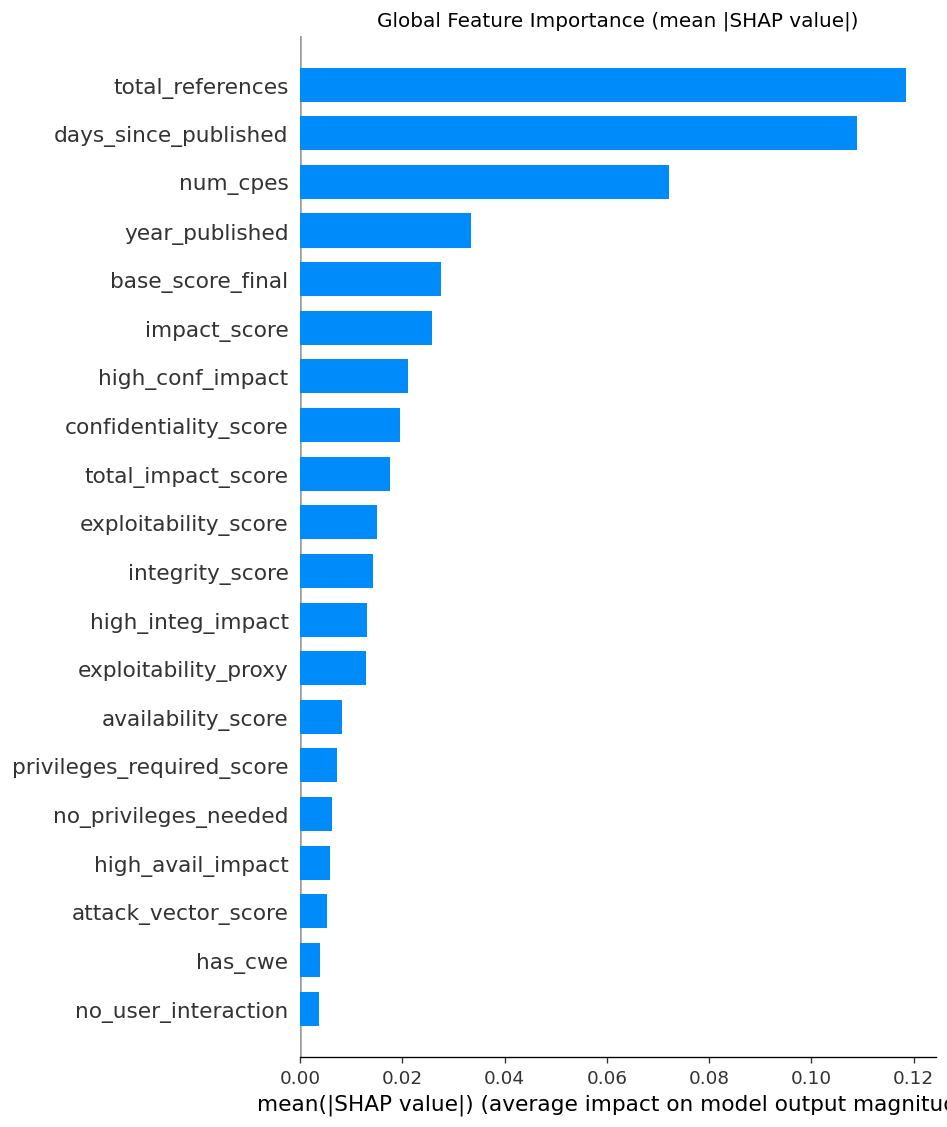

In [8]:
shap.summary_plot(
    shap_exploited,
    X_sample,
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.savefig('figures/14_shap_importance_bar.png', bbox_inches='tight')
plt.show()

In [9]:
# Ranked table of mean absolute SHAP values
mean_shap = pd.Series(
    np.abs(shap_exploited).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

print('Feature importance ranking (mean |SHAP|):')
print(mean_shap.round(6).to_string())

Feature importance ranking (mean |SHAP|):
total_references             0.118444
days_since_published         0.108852
num_cpes                     0.072173
year_published               0.033415
base_score_final             0.027517
impact_score                 0.025690
high_conf_impact             0.021175
confidentiality_score        0.019498
total_impact_score           0.017502
exploitability_score         0.014972
integrity_score              0.014268
high_integ_impact            0.012976
exploitability_proxy         0.012889
availability_score           0.008274
privileges_required_score    0.007149
no_privileges_needed         0.006223
high_avail_impact            0.005909
attack_vector_score          0.005265
has_cwe                      0.003879
no_user_interaction          0.003586
is_network_based             0.003529
user_interaction_score       0.003510
attack_complexity_score      0.001859
is_low_complexity            0.001772


## 4. Global Explainability — Feature Impact Direction

The beeswarm plot shows both the importance and the direction of each feature:
- Red = high feature value
- Blue = low feature value
- Position on x-axis = impact on prediction (positive = increases exploitation probability)

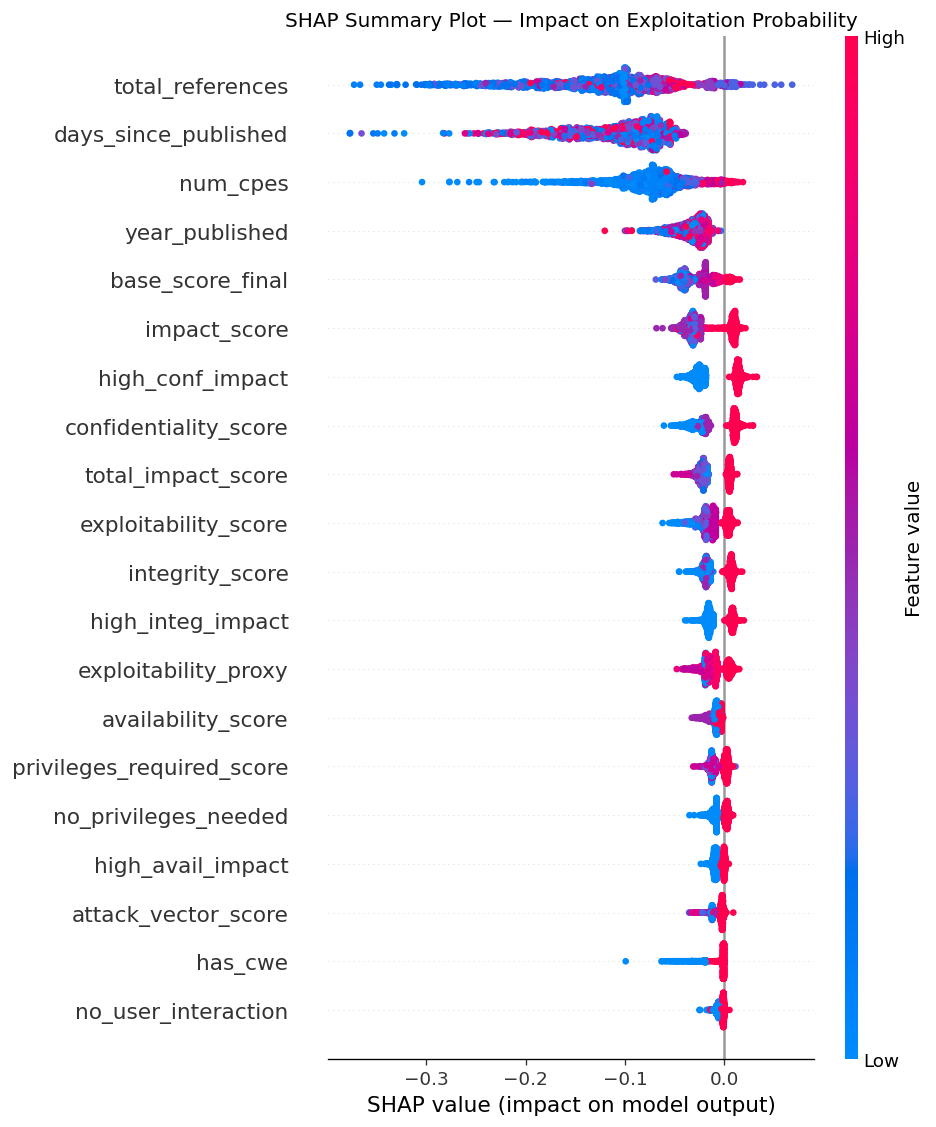

In [10]:
shap.summary_plot(
    shap_exploited,
    X_sample,
    show=False
)
plt.title('SHAP Summary Plot — Impact on Exploitation Probability')
plt.tight_layout()
plt.savefig('figures/15_shap_summary_beeswarm.png', bbox_inches='tight')
plt.show()

## 5. Local Explainability — Individual CVE Analysis

Waterfall plots explain individual predictions: why did the model predict high/low exploitation risk for a specific CVE.

In [11]:
# Find a true positive in the sample (exploited CVE correctly predicted)
y_sample = y_test.loc[X_sample.index]
y_pred_sample = rf.predict(X_sample)

true_positives  = X_sample[(y_sample.values == 1) & (y_pred_sample == 1)]
true_negatives  = X_sample[(y_sample.values == 0) & (y_pred_sample == 0)]

print(f'True positives in sample:  {len(true_positives)}')
print(f'True negatives in sample:  {len(true_negatives)}')

True positives in sample:  0
True negatives in sample:  1990


In [12]:
# Local explanation: high-risk CVE (true positive)
if len(true_positives) > 0:
    idx_tp = true_positives.index[0]
    pos_in_sample = X_sample.index.get_loc(idx_tp)

    explanation_tp = shap.Explanation(
        values=shap_exploited[pos_in_sample],
        base_values=explainer.expected_value[1],
        data=X_sample.iloc[pos_in_sample].values,
        feature_names=X_sample.columns.tolist()
    )

    shap.waterfall_plot(explanation_tp, show=False)
    plt.title('Local Explanation — High Risk CVE (True Positive)')
    plt.tight_layout()
    plt.savefig('figures/16_shap_waterfall_high_risk.png', bbox_inches='tight')
    plt.show()

    print('CVE features (high risk):')
    print(X_sample.loc[idx_tp].to_string())
else:
    print('No true positives found in sample. Increase SAMPLE_SIZE.')

No true positives found in sample. Increase SAMPLE_SIZE.


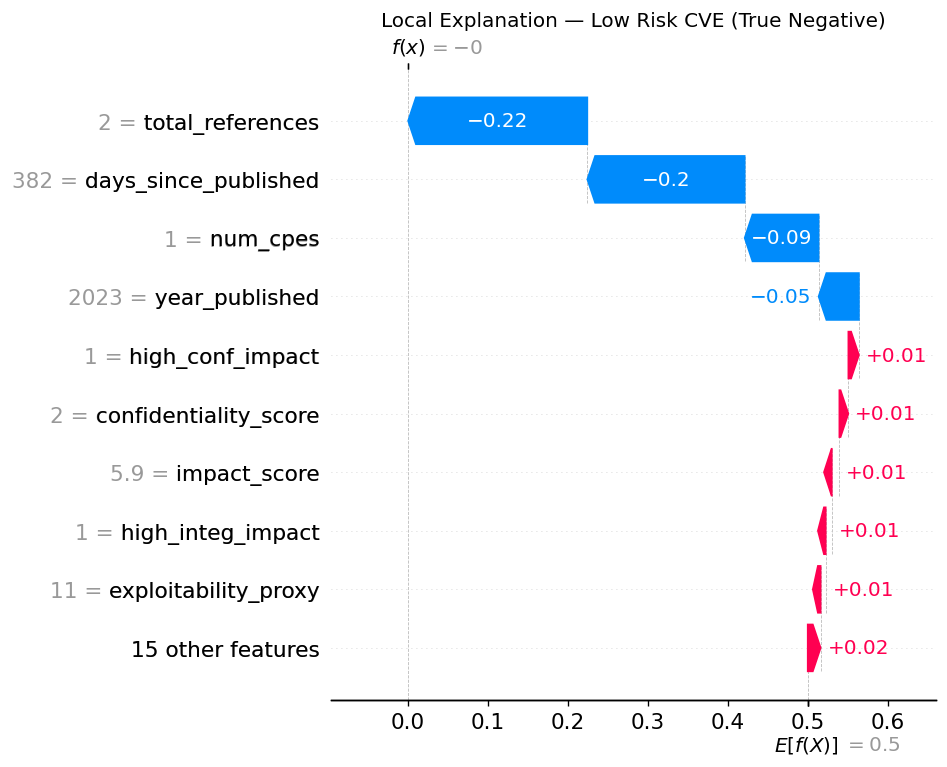

In [13]:
# Local explanation: low-risk CVE (true negative)
if len(true_negatives) > 0:
    idx_tn = true_negatives.index[0]
    pos_in_sample = X_sample.index.get_loc(idx_tn)

    explanation_tn = shap.Explanation(
        values=shap_exploited[pos_in_sample],
        base_values=explainer.expected_value[1],
        data=X_sample.iloc[pos_in_sample].values,
        feature_names=X_sample.columns.tolist()
    )

    shap.waterfall_plot(explanation_tn, show=False)
    plt.title('Local Explanation — Low Risk CVE (True Negative)')
    plt.tight_layout()
    plt.savefig('figures/17_shap_waterfall_low_risk.png', bbox_inches='tight')
    plt.show()
else:
    print('No true negatives found in sample.')

## 6. Key Findings for the Thesis

In [14]:
print('SHAP KEY FINDINGS')
print('=' * 60)

print('\nTop 5 most important features (global):')
for i, (feat, val) in enumerate(mean_shap.head(5).items(), 1):
    print(f'  {i}. {feat:<35}  mean |SHAP| = {val:.6f}')

print('\nBottom 5 least important features (global):')
for i, (feat, val) in enumerate(mean_shap.tail(5).items(), 1):
    print(f'  {i}. {feat:<35}  mean |SHAP| = {val:.6f}')

SHAP KEY FINDINGS

Top 5 most important features (global):
  1. total_references                     mean |SHAP| = 0.118444
  2. days_since_published                 mean |SHAP| = 0.108852
  3. num_cpes                             mean |SHAP| = 0.072173
  4. year_published                       mean |SHAP| = 0.033415
  5. base_score_final                     mean |SHAP| = 0.027517

Bottom 5 least important features (global):
  1. no_user_interaction                  mean |SHAP| = 0.003586
  2. is_network_based                     mean |SHAP| = 0.003529
  3. user_interaction_score               mean |SHAP| = 0.003510
  4. attack_complexity_score              mean |SHAP| = 0.001859
  5. is_low_complexity                    mean |SHAP| = 0.001772
